# Decision-Focused Learning 

In [1]:
import json
import time
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm
from scipy.optimize import minimize_scalar
from sklearn.preprocessing import StandardScaler
import torch
from torch import nn


ROOT = Path.cwd().resolve()
if not (ROOT / "empirical" / "data" / "processed" / "macro_panel_quarterly.csv").exists() and (ROOT / "dfl_for_capital_allocation").is_dir():
    ROOT = ROOT / "dfl_for_capital_allocation"
while ROOT != ROOT.parent and not (ROOT / "empirical" / "data" / "processed" / "macro_panel_quarterly.csv").exists():
    ROOT = ROOT.parent

import sys
sys.path.insert(0, str(ROOT))

from minou_colours import MINOU_COLOURS

FIGURES_DIR = ROOT / "empirical" / "figures" / "04_dfl"
RESULTS_DIR = ROOT / "empirical" / "results" / "dfl"
METADATA_PATH = ROOT / "empirical" / "data" / "processed" / "empirical_panel_metadata.json"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

## Configuration

In [2]:
# Data conventions
HORIZON = 1
DATE_COL = "DATE"
TARGET_COL = "charge_off_rate"

INCLUDE_CURRENT_CQ = True

with open(METADATA_PATH, "r", encoding="utf-8") as f:
    META = json.load(f)
CONST = META["constants"]

# Decision and Basel constants
CHARGE_OFF_IS_PERCENT = bool(CONST["CHARGE_OFF_IS_PERCENT"])
LGD = float(CONST["LGD"])
M = float(CONST["M"])
K1 = float(CONST["K1"])
LEVERAGE = float(CONST["ell"])
Y_BAR = float(CONST["Y_BAR"])
LAMBDA = float(CONST["lambda_shortfall"])
APPLY_PD_FLOOR = bool(CONST["APPLY_PD_FLOOR"])
PD_FLOOR = float(CONST["PD_FLOOR"])
assert LGD == 0.45 and K1 == 1.0 and LEVERAGE == 10.0, "Panel constants differ from expected calibration."
assert bool(CONST["INCLUDE_CURRENT_CQ"]) == INCLUDE_CURRENT_CQ, \
    "INCLUDE_CURRENT_CQ differs from the PTO notebook's panel metadata."

PD_Q_CLIP_LOW = float(CONST["PD_CLIP_LOW"])
PD_Q_CLIP_HIGH = float(CONST["PD_CLIP_HIGH"])
PD_A_CLIP_LOW = 1e-6
PD_A_CLIP_HIGH = 0.99


ALPHA_BOUNDS = (float(CONST["alpha_bounds_min"]), float(CONST["alpha_bounds_max"]))
ALPHA_OPT_XATOL = float(CONST["alpha_opt_xatol"])

# Expanding-window evaluation
FIRST_TEST_DATE = "2006-01-01"

from empirical.common import model_config as empirical_mcfg
DFL_SEEDS = empirical_mcfg.ENSEMBLE_SEEDS

RHO_SCALE = 0.03

## Quarterly PD, Basel IRB, and allocation objective

In [3]:
SIMULATION_ROOT = ROOT / "simulation"

sys.path.insert(0, str(SIMULATION_ROOT))

from common import decision as dec
from common import model_config as mcfg
from common import dfl_model
from common.decision import DecisionConfig
from empirical.common import data as emp_data

DCFG = DecisionConfig(
    LGD=LGD, K1=K1, ell=LEVERAGE, Y_BAR=Y_BAR, lambda_shortfall=LAMBDA, M=M, RHO_SCALE=RHO_SCALE,
    APPLY_PD_FLOOR=APPLY_PD_FLOOR, PD_FLOOR=PD_FLOOR,
    PD_Q_CLIP_LOW=PD_Q_CLIP_LOW, PD_Q_CLIP_HIGH=PD_Q_CLIP_HIGH,
    PD_A_CLIP_LOW=PD_A_CLIP_LOW, PD_A_CLIP_HIGH=PD_A_CLIP_HIGH,
    ALPHA_BOUNDS=ALPHA_BOUNDS, ALPHA_OPT_XATOL=ALPHA_OPT_XATOL,
)

DFL_MODEL_CFG = empirical_mcfg.make_model_config(mcfg.ModelConfig)
DFL_IMPLICIT_ALLOC_CLS = dfl_model.make_implicit_allocation(DCFG)
dfl_model.DFL_INCLUDE_RHO_CHANNEL = False

def clip_pd_q(pd_q):
    return dec.clip_pd_q(pd_q, DCFG)


def clip_pd_a(pd_a):
    return dec.clip_pd_a(pd_a, DCFG)


def quarterly_pd_to_annual(pd_q):
    return dec.quarterly_pd_to_annual(pd_q, DCFG)


def k_irb_from_annual_pd(pd_a, lgd=None, m=None, apply_floor=None):
    return dec.k_irb_from_annual_pd(pd_a, DCFG, lgd=lgd, m=m, apply_floor=apply_floor)



def decision_components(alpha, c_q, pd_a):
    k = dec.k_irb_from_annual_pd(pd_a, DCFG)
    return dec.decision_components(alpha, c_q, k, DCFG)


def optimise_alpha_continuous(c_q, pd_a):
    k = dec.k_irb_from_annual_pd(pd_a, DCFG)
    return dec.optimise_alpha_oracle(c_q, k, DCFG)

## Load and align data


In [4]:
macro_csv = ROOT / "empirical" / "data" / "processed" / "macro_panel_quarterly.csv"
df = emp_data.load_quarterly_pd_panel(
    macro_csv, dcfg=DCFG, date_col=DATE_COL, target_col=TARGET_COL, horizon=HORIZON,
    charge_off_is_percent=CHARGE_OFF_IS_PERCENT,
    include_current_cq=INCLUDE_CURRENT_CQ)
feature_cols = df.attrs["feature_cols"]

print(f"Observations after alignment and one-step target: {len(df)}")
print(f"Feature date range: {df[DATE_COL].min().date()} to {df[DATE_COL].max().date()}")
print(f"Target date range: {df['target_date'].min().date()} to {df['target_date'].max().date()}")
print(f"Features ({len(feature_cols)}): {feature_cols}")
assert "c_q_lag1" in feature_cols
assert ("c_q" in feature_cols) == INCLUDE_CURRENT_CQ
assert not any(col.startswith("pd_q") or col.startswith("pd_a") for col in feature_cols)
print(f"Lag features included: c_q_lag1{' and current-quarter c_q' if INCLUDE_CURRENT_CQ else ''}; PD columns excluded.")
display(df.head())

# Foresight-oracle allocation and utility for training
_oracle = [optimise_alpha_continuous(c_q=float(c), pd_a=float(p))
           for c, p in zip(df["c_q_realised"], df["pd_a_realised"])]
df["alpha_oracle_next"] = [a for a, _ in _oracle]
df["utility_oracle_next"] = [u for _, u in _oracle]

# Capital requirement
df["k_irb_realised_next"] = k_irb_from_annual_pd(df["pd_a_realised"].to_numpy())
assert not set(["alpha_oracle_next", "utility_oracle_next", "k_irb_realised_next"]) & set(feature_cols)


Observations after alignment and one-step target: 142
Feature date range: 1990-07-01 to 2025-10-01
Target date range: 1990-10-01 to 2026-01-01
Features (14): ['real_gdp_growth', 'unemployment_rate', 'industrial_production', 'real_disposable_personal_income', 'cpi', 'house_price_index', 'federal_funds_rate', 'treasury_10y_2y_spread', 'vix', 'corporate_bond_spread', 'senior_loan_officer_survey', 'excess_bond_premium', 'c_q', 'c_q_lag1']
Lag features included: c_q_lag1 and current-quarter c_q; PD columns excluded.


,DATE,real_gdp_growth,unemployment_rate,industrial_production,real_disposable_personal_income,cpi,house_price_index,federal_funds_rate,treasury_10y_2y_spread,vix,...,c_q,pd_q,pd_a,c_q_lag1,target_date,c_annual_raw_next,c_q_realised,pd_q_realised,pd_a_realised,target_pd_q_next
0,1990-07-01,0.3,5.700000,0.386851,0.014248,1.712502,0.607283,8.160000,0.602540,25.195556,...,0.003200,0.007111,0.028142,0.003575,1990-10-01,1.30,0.003250,0.007222,0.028577,0.007222
1,1990-10-01,-3.6,6.133333,-1.560018,-0.804251,1.683668,-0.390403,7.743333,0.800161,26.113281,...,0.003250,0.007222,0.028577,0.003200,1991-01-01,1.48,0.003700,0.008222,0.032485,0.008222
2,1991-01-01,-1.9,6.600000,-1.932577,0.306683,0.744790,0.833014,6.426667,0.987167,22.515833,...,0.003700,0.008222,0.032485,0.003250,1991-04-01,1.86,0.004650,0.010333,0.040697,0.010333
3,1991-04-01,3.2,6.833333,0.526353,0.748178,0.591864,0.660265,5.863333,1.231406,17.147031,...,0.004650,0.010333,0.040697,0.003700,1991-07-01,1.97,0.004925,0.010944,0.043064,0.010944
4,1991-07-01,2.0,6.866667,1.390822,0.383417,0.759342,0.195457,5.643333,1.428906,16.634219,...,0.004925,0.010944,0.043064,0.004650,1991-10-01,1.83,0.004575,0.010167,0.040051,0.010167


## Expanding-window evaluation

In [5]:
def build_result_row_dfl(base_row, pd_q_hat, model_name, pd_q_hat_std=float("nan")):
    pd_q_hat = float(clip_pd_q(pd_q_hat))
    c_q_hat = float(LGD * pd_q_hat)
    pd_a_hat = float(quarterly_pd_to_annual(pd_q_hat))
    c_q_realised = float(base_row["c_q_realised"])
    pd_q_realised = float(base_row["pd_q_realised"])
    pd_a_realised = float(base_row["pd_a_realised"])

    _alpha_raw, _ = dfl_model.solve_alpha_star(np.array([pd_q_hat]), DCFG)
    alpha_hat = float(_alpha_raw[0])
    alpha_oracle, utility_oracle = optimise_alpha_continuous(c_q=c_q_realised, pd_a=pd_a_realised)
    realised_components = decision_components(alpha_hat, c_q=c_q_realised, pd_a=pd_a_realised)
    oracle_components = decision_components(alpha_oracle, c_q=c_q_realised, pd_a=pd_a_realised)
    predicted_components = decision_components(alpha_hat, c_q=c_q_hat, pd_a=pd_a_hat)
    regret = utility_oracle - realised_components["utility"]

    return {"model": model_name, "date": pd.to_datetime(base_row["target_date"]),
            "feature_date": pd.to_datetime(base_row[DATE_COL]), "c_annual_raw": float(base_row["c_annual_raw_next"]),
            "c_q_lag1": float(base_row["c_q_lag1"]),
            "c_q_realised": c_q_realised, "pd_q_realised": pd_q_realised, "pd_a_realised": pd_a_realised,
            "pd_q_hat": pd_q_hat, "pd_q_hat_std": float(pd_q_hat_std), "pd_a_hat": pd_a_hat, "c_q_hat": c_q_hat,
            "k_irb_realised": float(k_irb_from_annual_pd(pd_a_realised)), "k_irb_hat": float(k_irb_from_annual_pd(pd_a_hat)),
            "alpha_oracle": alpha_oracle, "alpha_hat": alpha_hat,
            "utility_oracle": utility_oracle,
            "utility": realised_components["utility"], "regret": regret,
            "shortfall_oracle": oracle_components["shortfall"],
            "shortfall_realised_at_hat": realised_components["shortfall"],
            "shortfall_predicted_at_hat": predicted_components["shortfall"]}


def resolve_first_test_idx(df, first_test_date):
    mask = (df["target_date"] >= pd.Timestamp(first_test_date)).to_numpy()
    if not mask.any():
        raise ValueError("first_test_date is after the last available target date.")
    first_test_idx = int(np.flatnonzero(mask)[0])
    if first_test_idx < 30 or len(df) - first_test_idx < 5:
        raise ValueError(f"Evaluation leaves too little data: first_test_idx={first_test_idx} of {len(df)}.")
    return first_test_idx


def run_expanding_window_pd_irb(df, feature_cols, first_test_date, model_cfg=DFL_MODEL_CFG,
                                return_history=True, stability_reference_X=None):
    first_test_idx = resolve_first_test_idx(df, first_test_date)
    total = len(df) - first_test_idx
    print(f"First test target: {pd.Timestamp(df['target_date'].iloc[first_test_idx]).date()}, "
          f"{total} windows, {first_test_idx} initial training obs")
    records, histories = [], []
    stability_linear_rows, stability_mlp_rows = [], []
    t0 = time.time()
    for test_idx in range(first_test_idx, len(df)):
        train_df = df.iloc[:test_idx]
        test_row = df.iloc[test_idx]
        scaler = StandardScaler()
        x_train = scaler.fit_transform(train_df[feature_cols].to_numpy(dtype=float))
        y_train = train_df["target_pd_q_next"].to_numpy(dtype=float)
        x_test = scaler.transform(test_row[feature_cols].to_numpy(dtype=float).reshape(1, -1))

        c_next_tr = train_df["c_q_realised"].to_numpy(dtype=float)
        k_next_tr = train_df["k_irb_realised_next"].to_numpy(dtype=float)
        u_oracle_tr = train_df["utility_oracle_next"].to_numpy(dtype=float)
        dfl_linear_model, dfl_linear_hist = dfl_model.train_dfl_model(
            x_train, y_train, c_next_tr, k_next_tr, u_oracle_tr, "linear",
            model_cfg, DCFG, DFL_IMPLICIT_ALLOC_CLS, return_history=True)
        records.append(build_result_row_dfl(
            test_row, float(dfl_model.predict_pd_q(dfl_linear_model, x_test, DCFG)[0]),
            "dfl_linear"))
        
        if stability_reference_X is not None:
            _x_ref_lin = scaler.transform(stability_reference_X)
            _ref_pred_lin = dfl_model.predict_pd_q(dfl_linear_model, _x_ref_lin, DCFG)
            _ref_alpha_lin, _ = dfl_model.solve_alpha_star(np.asarray(_ref_pred_lin), DCFG)
            _row_lin = {"refit_step": test_idx - first_test_idx,
                        "test_date": pd.to_datetime(test_row["target_date"]),
                        "train_end_date": pd.to_datetime(train_df[DATE_COL].iloc[-1]),
                        "n_train": len(train_df)}
            for _i, _p in enumerate(_ref_pred_lin):
                _row_lin[f"ref{_i}_pd_q_hat_mean"] = float(_p)
            for _i, _a in enumerate(_ref_alpha_lin):
                _row_lin[f"ref{_i}_alpha_hat_mean"] = float(_a)
            stability_linear_rows.append(_row_lin)

        dfl_mlp_models, dfl_mlp_hist = dfl_model.train_dfl_ensemble(
            x_train, y_train, c_next_tr, k_next_tr, u_oracle_tr, model_cfg, DCFG,
            DFL_IMPLICIT_ALLOC_CLS, seeds=DFL_SEEDS, return_history=True)
        dfl_mean, dfl_std = dfl_model.predict_pd_q_ensemble(dfl_mlp_models, x_test, DCFG)
        records.append(build_result_row_dfl(test_row, float(dfl_mean[0]), "dfl_mlp",
                                            pd_q_hat_std=float(dfl_std[0])))
       
        if stability_reference_X is not None:
            _x_ref = scaler.transform(stability_reference_X)
            _member_pd = np.stack([dfl_model.predict_pd_q(m, _x_ref, DCFG) for m in dfl_mlp_models], axis=0)
            _ref_mean, _ref_std = _member_pd.mean(axis=0), _member_pd.std(axis=0)
            _ref_alpha_mlp, _ = dfl_model.solve_alpha_star(np.asarray(_ref_mean), DCFG)
            _row = {"refit_step": test_idx - first_test_idx,
                    "test_date": pd.to_datetime(test_row["target_date"]),
                    "train_end_date": pd.to_datetime(train_df[DATE_COL].iloc[-1]), "n_train": len(train_df)}
            for _i, (_m, _s) in enumerate(zip(_ref_mean, _ref_std)):
                _row[f"ref{_i}_pd_q_hat_mean"] = float(_m)
                _row[f"ref{_i}_pd_q_hat_std"] = float(_s)
                for _seed, _pred in zip(DFL_SEEDS, _member_pd[:, _i]):
                    _row[f"ref{_i}_pd_q_hat_seed{int(_seed)}"] = float(_pred)
                    _a_seed, _ = dfl_model.solve_alpha_star(np.asarray([_pred]), DCFG)
                    _row[f"ref{_i}_alpha_hat_seed{int(_seed)}"] = float(_a_seed[0])
            for _i, _a in enumerate(_ref_alpha_mlp):
                _row[f"ref{_i}_alpha_hat_mean"] = float(_a)
            stability_mlp_rows.append(_row)

        if return_history:
            for hist in (dfl_linear_hist, dfl_mlp_hist):
                if hist is not None:
                    hist = hist.copy()
                    hist["test_date"] = pd.to_datetime(test_row["target_date"])
                    hist["train_end_date"] = pd.to_datetime(train_df[DATE_COL].iloc[-1])
                    histories.append(hist)

        done = test_idx - first_test_idx + 1
        if done % 5 == 0 or test_idx == len(df) - 1:
            print(f"Completed {done}/{total} windows ({time.time() - t0:.0f}s elapsed)")
    pred_long = pd.DataFrame(records).sort_values(["date", "model"]).reset_index(drop=True)
    history = pd.concat(histories, ignore_index=True) if histories else pd.DataFrame()
    stability_linear = pd.DataFrame(stability_linear_rows)
    stability_mlp = pd.DataFrame(stability_mlp_rows)
    return pred_long, history, stability_linear, stability_mlp

STABILITY_REF_X, STABILITY_REF_DATES = df[feature_cols].to_numpy(dtype=float), df[DATE_COL].to_numpy()

pl, th, sl, sm = run_expanding_window_pd_irb(
    df, feature_cols, FIRST_TEST_DATE, stability_reference_X=STABILITY_REF_X)
pred_long, training_history, stability_linear, stability_mlp = pl, th, sl, sm
display(pred_long.head())

First test target: 2006-01-01, 81 windows, 61 initial training obs
Completed 5/81 windows (199s elapsed)
Completed 10/81 windows (348s elapsed)
Completed 15/81 windows (484s elapsed)
Completed 20/81 windows (604s elapsed)
Completed 25/81 windows (758s elapsed)
Completed 30/81 windows (898s elapsed)
Completed 35/81 windows (1113s elapsed)
Completed 40/81 windows (1508s elapsed)
Completed 45/81 windows (1818s elapsed)
Completed 50/81 windows (2223s elapsed)
Completed 55/81 windows (2601s elapsed)
Completed 60/81 windows (2969s elapsed)
Completed 65/81 windows (3149s elapsed)
Completed 70/81 windows (3293s elapsed)
Completed 75/81 windows (3429s elapsed)
Completed 80/81 windows (3560s elapsed)
Completed 81/81 windows (3591s elapsed)


,model,date,feature_date,c_annual_raw,c_q_lag1,c_q_realised,pd_q_realised,pd_a_realised,pd_q_hat,pd_q_hat_std,...,k_irb_realised,k_irb_hat,alpha_oracle,alpha_hat,utility_oracle,utility,regret,shortfall_oracle,shortfall_realised_at_hat,shortfall_predicted_at_hat
0,dfl_linear,2006-01-01,2005-10-01,0.21,0.000525,0.000525,0.001167,0.004659,0.001877,NaN,...,0.053913,0.066182,0.726543,0.663033,1.118245,1.107909,0.010336,0.0,0.000000,0.0
1,dfl_mlp,2006-01-01,2005-10-01,0.21,0.000525,0.000525,0.001167,0.004659,0.003346,0.001686,...,0.053913,0.081384,0.726543,0.598637,1.118245,1.097428,0.020817,0.0,0.000000,0.0
2,dfl_linear,2006-04-01,2006-01-01,0.27,0.000775,0.000675,0.001500,0.005987,0.003002,NaN,...,0.060307,0.078560,0.693570,0.609802,1.111838,1.098331,0.013508,0.0,0.000000,0.0
3,dfl_mlp,2006-04-01,2006-01-01,0.27,0.000775,0.000675,0.001500,0.005987,0.003299,0.001885,...,0.060307,0.081022,0.693570,0.600052,1.111838,1.096758,0.015080,0.0,0.000000,0.0
4,dfl_linear,2006-07-01,2006-04-01,0.30,0.000525,0.000750,0.001667,0.006650,0.001326,NaN,...,0.063051,0.057144,0.680266,0.707304,1.109183,0.716056,0.393127,0.0,0.039747,0.0


## Result collection

In [9]:
base_cols = ["date", "c_annual_raw", "c_q_lag1", "c_q_realised", "pd_q_realised", "pd_a_realised",
             "k_irb_realised", "alpha_oracle", "utility_oracle"]
metric_cols = ["pd_q_hat", "pd_a_hat", "c_q_hat", "k_irb_hat", "alpha_hat", "utility", "regret"]
MODEL_ORDER = ["dfl_linear", "dfl_mlp"]

def make_wide_results(pred_long):
    sub = pred_long
    wide = sub.pivot(index="date", columns="model", values=metric_cols).sort_index()
    wide.columns = [f"{metric}_{model}" for metric, model in wide.columns]
    wide = wide.reset_index()
    base = sub[sub["model"] == "dfl_linear"][base_cols].copy()
    out = base.merge(wide, on="date", how="left")
    ordered = base_cols + [f"{m}_{mod}" for m in metric_cols for mod in MODEL_ORDER]
    return out[ordered].sort_values("date").reset_index(drop=True)

results = make_wide_results(pred_long)
output_csv = RESULTS_DIR / "dfl_quarterly_pd_irb_predictions.csv"
results.to_csv(output_csv, index=False)
print(f"Saved {len(results)} rows to {output_csv.relative_to(ROOT)}")

lin_sub = stability_linear
mlp_sub = stability_mlp
lin_csv = RESULTS_DIR / "dfl_stability_linear_reference_outputs.csv"
mlp_csv = RESULTS_DIR / "dfl_stability_mlp_reference_outputs.csv"
lin_sub.to_csv(lin_csv, index=False)
mlp_sub.to_csv(mlp_csv, index=False)
print(f"Saved {len(lin_sub)} linear reference-output rows to {lin_csv.relative_to(ROOT)}")
print(f"Saved {len(mlp_sub)} MLP reference-output rows to {mlp_csv.relative_to(ROOT)}")
display(results.head())

Saved 81 rows to empirical/results/dfl/dfl_quarterly_pd_irb_predictions.csv
Saved 81 linear reference-output rows to empirical/results/dfl/dfl_stability_linear_reference_outputs.csv
Saved 81 MLP reference-output rows to empirical/results/dfl/dfl_stability_mlp_reference_outputs.csv


,date,c_annual_raw,c_q_lag1,c_q_realised,pd_q_realised,pd_a_realised,k_irb_realised,alpha_oracle,utility_oracle,pd_q_hat_dfl_linear,...,c_q_hat_dfl_linear,c_q_hat_dfl_mlp,k_irb_hat_dfl_linear,k_irb_hat_dfl_mlp,alpha_hat_dfl_linear,alpha_hat_dfl_mlp,utility_dfl_linear,utility_dfl_mlp,regret_dfl_linear,regret_dfl_mlp
0,2006-01-01,0.21,0.000525,0.000525,0.001167,0.004659,0.053913,0.726543,1.118245,0.001877,...,0.000845,0.001506,0.066182,0.081384,0.663033,0.598637,1.107909,1.097428,0.010336,0.020817
1,2006-04-01,0.27,0.000775,0.000675,0.001500,0.005987,0.060307,0.693570,1.111838,0.003002,...,0.001351,0.001485,0.078560,0.081022,0.609802,0.600052,1.098331,1.096758,0.013508,0.015080
2,2006-07-01,0.30,0.000525,0.000750,0.001667,0.006650,0.063051,0.680266,1.109183,0.001326,...,0.000597,0.001112,0.057144,0.073435,0.707304,0.630936,0.716056,1.101265,0.393127,0.007917
3,2006-10-01,0.34,0.000675,0.000850,0.001889,0.007534,0.066343,0.664926,1.106056,0.001553,...,0.000699,0.001378,0.061205,0.079074,0.686770,0.607748,0.781017,1.096936,0.325039,0.009120
4,2007-01-01,0.37,0.000750,0.000925,0.002056,0.008197,0.068577,0.654869,1.103960,0.002225,...,0.001001,0.001559,0.070670,0.082285,0.642852,0.595141,1.102053,1.094479,0.001908,0.009482


## Diagnostics and sanity checks

In [7]:
def describe_columns(frame, cols):
    return frame[cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T

# PD checks
assert np.allclose(pred_long["pd_q_realised"], clip_pd_q(pred_long["c_q_realised"] / LGD))
assert np.allclose(pred_long["pd_a_realised"], quarterly_pd_to_annual(pred_long["pd_q_realised"]), atol=1e-12)
for col in ["pd_q_realised", "pd_a_realised"]:
    vals = pred_long[col].to_numpy()
    assert np.isfinite(vals).all() and (vals > 0.0).all() and (vals < 1.0).all(), col
vals = pred_long["k_irb_realised"].to_numpy()
assert np.isfinite(vals).all() and (vals >= 0.0).all()
for col in ["pd_q_hat", "pd_a_hat"]:
    vals = pred_long[col].to_numpy()
    assert np.isfinite(vals).all() and (vals > 0.0).all() and (vals < 1.0).all(), col
vals = pred_long["k_irb_hat"].to_numpy()
assert np.isfinite(vals).all() and (vals >= 0.0).all()
assert np.allclose(pred_long["pd_a_hat"], quarterly_pd_to_annual(pred_long["pd_q_hat"]), atol=1e-12)
assert np.allclose(pred_long["k_irb_hat"], k_irb_from_annual_pd(pred_long["pd_a_hat"].to_numpy()), atol=1e-12)
print("IRB check passed: k_irb_from_annual_pd is called on annualised PD columns only.")

# DFL guards: alpha bounded
dfl_alpha = pred_long["alpha_hat"].to_numpy()
assert np.isfinite(dfl_alpha).all() and (dfl_alpha >= ALPHA_BOUNDS[0] - 1e-12).all() and (dfl_alpha <= ALPHA_BOUNDS[1] + 1e-12).all()
_resolved, _ = dfl_model.solve_alpha_star(pred_long["pd_q_hat"].to_numpy(), DCFG)
assert np.allclose(_resolved, dfl_alpha, atol=1e-8), "solve_alpha_star is not reproducible."
print("DFL guards passed (finite PD fields, alphas within [0, 1], solver reproducible).")

# Notebook consistency check
_oracle_check = df[["target_date", "alpha_oracle_next", "utility_oracle_next"]].rename(
    columns={"target_date": "date"})
_merged = pred_long.merge(_oracle_check, on="date", how="left")
assert np.allclose(_merged["alpha_oracle"], _merged["alpha_oracle_next"], atol=1e-8), \
    "Recomputed foresight oracle disagrees with the precomputed training-signal oracle."
assert np.allclose(_merged["utility_oracle"], _merged["utility_oracle_next"], atol=1e-8), \
    "Recomputed foresight-oracle utility disagrees with the precomputed training-signal value."
print("Cross-notebook oracle consistency check passed (training signal vs evaluation-time oracle).")

# Regret check
min_regret = pred_long["regret"].min()
if min_regret < -1e-6:
    raise AssertionError(f"Meaningfully negative regret found: {min_regret}")
print(f"Minimum regret across splits and models: {min_regret:.3e}")

summary_cols = (["c_annual_raw", "c_q_lag1", "c_q_realised", "pd_q_realised"]
                + [f"pd_q_hat_{m}" for m in MODEL_ORDER]
                + ["pd_a_realised"] + [f"pd_a_hat_{m}" for m in MODEL_ORDER]
                + ["k_irb_realised"] + [f"k_irb_hat_{m}" for m in MODEL_ORDER]
                + ["alpha_oracle"] + [f"alpha_hat_{m}" for m in MODEL_ORDER]
                + [f"regret_{m}" for m in MODEL_ORDER])
print("=== Evaluation summary ===")
display(describe_columns(results, summary_cols))

shortfall_summary = pred_long.groupby(["model"])[["shortfall_realised_at_hat", "shortfall_predicted_at_hat"]].agg(
    ["mean", "max", lambda s: float((s > 1e-12).mean())])
shortfall_summary = shortfall_summary.rename(columns={"<lambda_0>": "bind_share"})
print(f"Decision constants: LEVERAGE={LEVERAGE}, Y_BAR={Y_BAR}, LAMBDA={LAMBDA}")
display(shortfall_summary)

dfl_std_desc = pred_long[pred_long["model"] == "dfl_mlp"]["pd_q_hat_std"].describe()
print("Cross-seed std of DFL MLP ensemble PD predictions:")
display(dfl_std_desc)

IRB check passed: k_irb_from_annual_pd is called on annualised PD columns only.
DFL guards passed (finite PD fields, alphas within [0, 1], solver reproducible).
Cross-notebook oracle consistency check passed (training signal vs evaluation-time oracle).
Minimum regret across splits and models: 6.932e-04
=== Evaluation summary ===


,count,mean,std,min,5%,25%,50%,75%,95%,max
c_annual_raw,81.0,0.578025,0.540653,0.120000,0.160000,0.270000,0.410000,0.570000,1.940000,2.570000
c_q_lag1,81.0,0.001426,0.001357,0.000300,0.000400,0.000675,0.000925,0.001400,0.004850,0.006425
c_q_realised,81.0,0.001445,0.001352,0.000300,0.000400,0.000675,0.001025,0.001425,0.004850,0.006425
pd_q_realised,81.0,0.003211,0.003004,0.000667,0.000889,0.001500,0.002278,0.003167,0.010778,0.014278
pd_q_hat_dfl_linear,81.0,0.007674,0.014813,0.001326,0.001687,0.002575,0.003227,0.004781,0.023627,0.084133
pd_q_hat_dfl_mlp,81.0,0.005693,0.005132,0.002024,0.002197,0.003221,0.004046,0.005522,0.015032,0.039046
pd_a_realised,81.0,0.012730,0.011780,0.002664,0.003551,0.005987,0.009080,0.012607,0.042419,0.055900
pd_a_hat_dfl_linear,81.0,0.029113,0.052990,0.005295,0.006731,0.010259,0.012845,0.018989,0.091213,0.296394
pd_a_hat_dfl_mlp,81.0,0.022427,0.019590,0.008071,0.008760,0.012822,0.016085,0.021906,0.058786,0.147271
k_irb_realised,81.0,0.073241,0.018722,0.040918,0.047346,0.060307,0.071294,0.079955,0.113696,0.124536


Decision constants: LEVERAGE=10.0, Y_BAR=0.0168, LAMBDA=10.0


shortfall_realised_at_hat                       \
                                mean       max bind_share   
model                                                       
dfl_linear                  0.003441  0.073108   0.111111   
dfl_mlp                     0.000000  0.000000   0.000000   

           shortfall_predicted_at_hat                  
                                 mean  max bind_share  
model                                                  
dfl_linear                        0.0  0.0        0.0  
dfl_mlp                           0.0  0.0        0.0

Cross-seed std of DFL MLP ensemble PD predictions:


count    81.000000
mean      0.001588
std       0.002276
min       0.000086
25%       0.000576
50%       0.001046
75%       0.001548
max       0.018054
Name: pd_q_hat_std, dtype: float64

## Plots

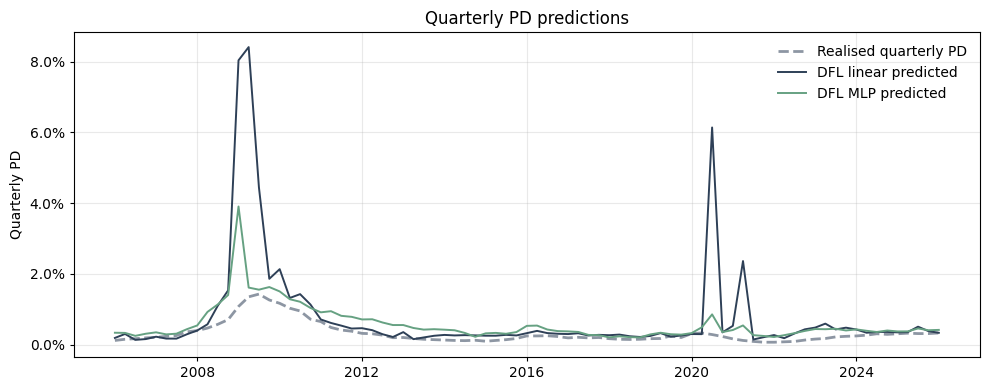

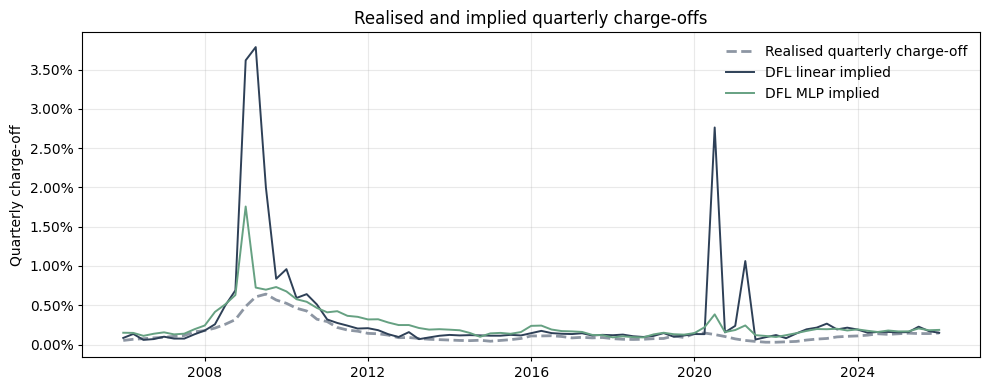

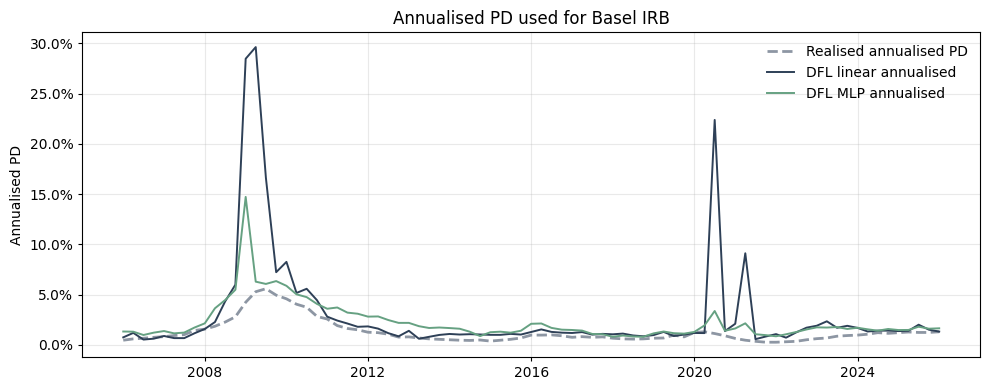

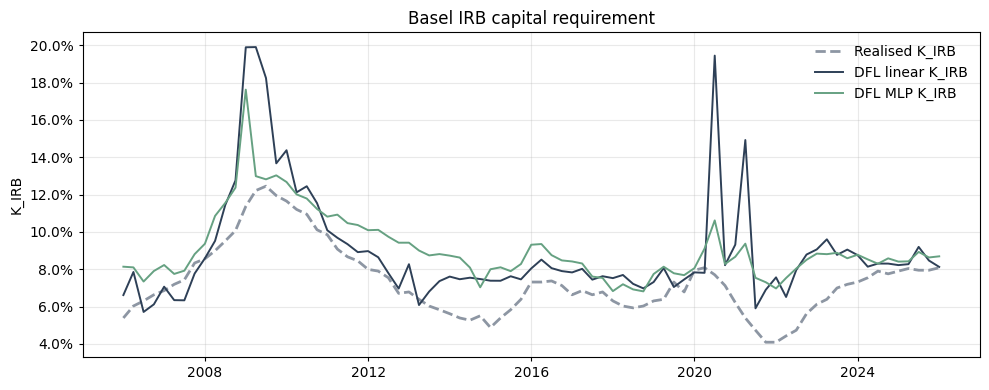

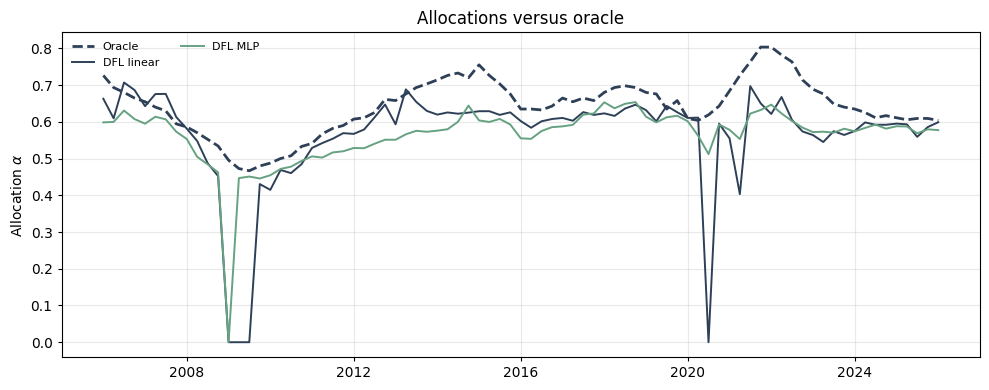

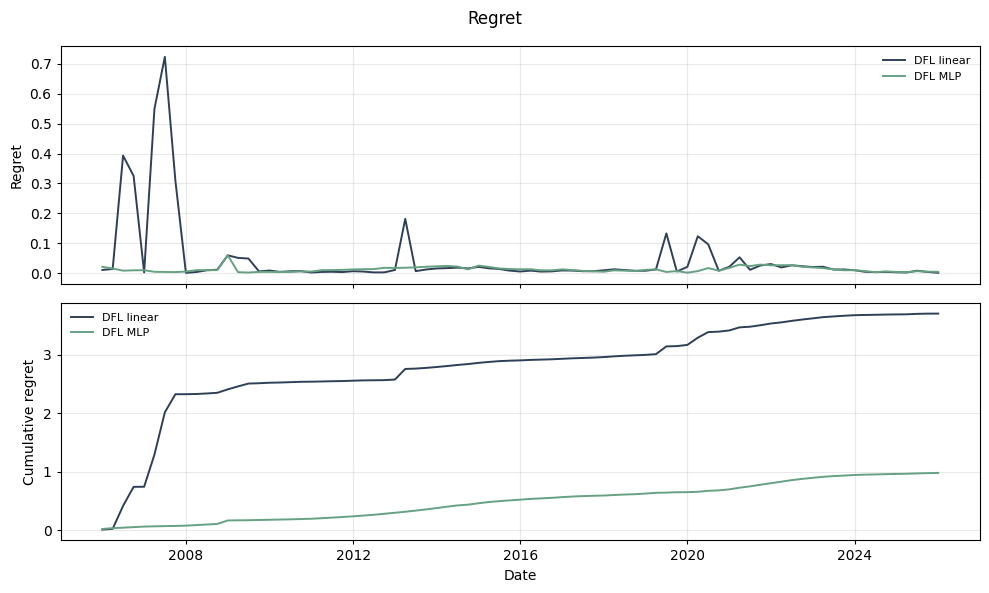

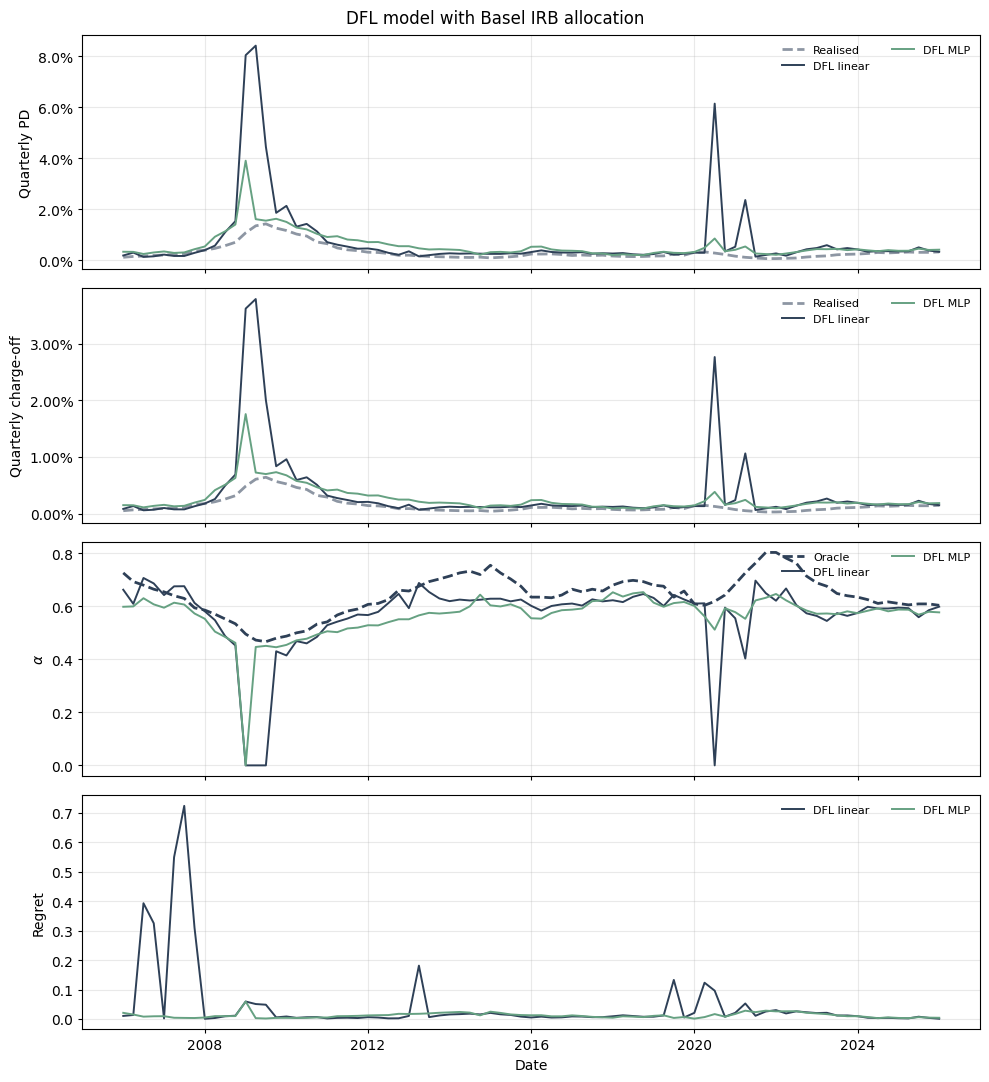

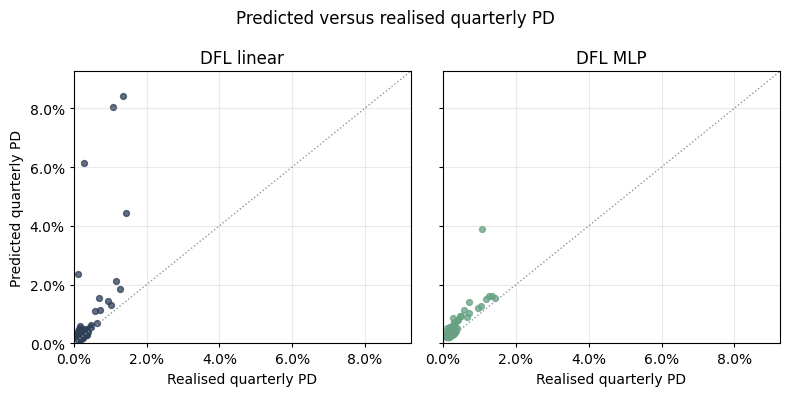

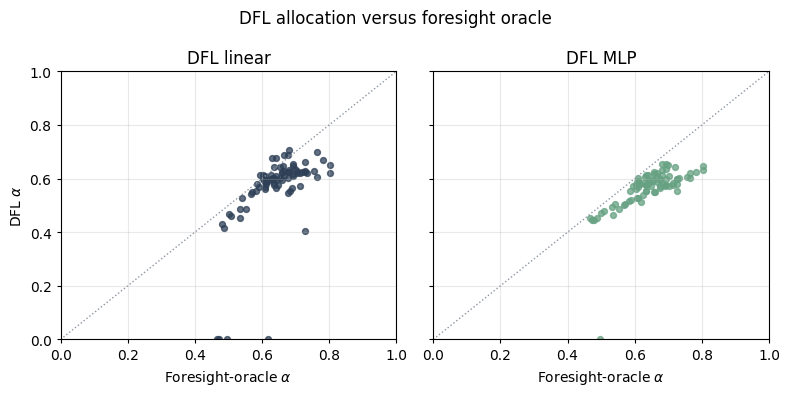

In [11]:
plt.rcdefaults()
plt.rcParams.update({"font.size": 10, "axes.linewidth": 0.8, "xtick.direction": "out", "ytick.direction": "out",
                     "xtick.major.size": 3, "ytick.major.size": 3, "font.sans-serif": ["DejaVu Sans"]})
from minou_colours import MINOU_COLOURS
MODEL_COLORS = {"dfl_linear": MINOU_COLOURS["navy"], "dfl_mlp": MINOU_COLOURS["sage"]}
MODEL_LW = {"dfl_linear": 1.4, "dfl_mlp": 1.4}
MODEL_LABELS = {"dfl_linear": "DFL linear", "dfl_mlp": "DFL MLP"}
ORACLE_COLOR = MINOU_COLOURS["navy"]
REAL_COLOR = MINOU_COLOURS["grey"]

PLOT_MODELS = ["dfl_linear", "dfl_mlp"]

def format_date_axis(ax, year_step=2):
    ax.xaxis.set_major_locator(mdates.YearLocator(year_step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, alpha=0.28)


def _model_lines(ax, plot_df, col_prefix, suffix="", models=None):
    for m in (PLOT_MODELS if models is None else models):
        ax.plot(plot_df["date"], plot_df[f"{col_prefix}_{m}"], color=MODEL_COLORS[m],
                lw=MODEL_LW[m], label=f"{MODEL_LABELS[m]}{suffix}")


def plot_results(res):
    fig_dir = FIGURES_DIR
    fig_dir.mkdir(parents=True, exist_ok=True)
    plot_df = res.sort_values("date").copy()
    year_step = 2 if len(plot_df) <= 60 else 4

    # 1. Quarterly PD predictions
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(plot_df["date"], plot_df["pd_q_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised quarterly PD")
    _model_lines(ax, plot_df, "pd_q_hat", " predicted")
    ax.set_ylabel("Quarterly PD"); ax.set_title("Quarterly PD predictions")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    format_date_axis(ax, year_step); ax.legend(frameon=False); plt.tight_layout()
    plt.savefig(fig_dir / "quarterly_pd_predictions.png", dpi=200, bbox_inches="tight"); plt.show()

    # 2. Quarterly charge-off predictions
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(plot_df["date"], plot_df["c_q_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised quarterly charge-off")
    _model_lines(ax, plot_df, "c_q_hat", " implied")
    ax.set_ylabel("Quarterly charge-off"); ax.set_title("Realised and implied quarterly charge-offs")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    format_date_axis(ax, year_step); ax.legend(frameon=False); plt.tight_layout()
    plt.savefig(fig_dir / "quarterly_chargeoff_predictions.png", dpi=200, bbox_inches="tight"); plt.show()

    # 3. Annualised PD for IRB
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(plot_df["date"], plot_df["pd_a_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised annualised PD")
    _model_lines(ax, plot_df, "pd_a_hat", " annualised")
    ax.set_ylabel("Annualised PD"); ax.set_title("Annualised PD used for Basel IRB")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    format_date_axis(ax, year_step); ax.legend(frameon=False); plt.tight_layout()
    plt.savefig(fig_dir / "annualised_pd_irb.png", dpi=200, bbox_inches="tight"); plt.show()

    # 4. IRB capital requirement
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(plot_df["date"], plot_df["k_irb_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised K_IRB")
    _model_lines(ax, plot_df, "k_irb_hat", " K_IRB")
    ax.set_ylabel("K_IRB"); ax.set_title("Basel IRB capital requirement")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    format_date_axis(ax, year_step); ax.legend(frameon=False); plt.tight_layout()
    plt.savefig(fig_dir / "irb_capital_requirement.png", dpi=200, bbox_inches="tight"); plt.show()

    # 5. Allocation comparison
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(plot_df["date"], plot_df["alpha_oracle"], color=ORACLE_COLOR, lw=2, ls="--", label="Oracle")
    _model_lines(ax, plot_df, "alpha_hat")
    ax.set_ylabel(r"Allocation $\alpha$"); ax.set_title("Allocations versus oracle")
    format_date_axis(ax, year_step); ax.legend(frameon=False, fontsize=8, ncol=2); plt.tight_layout()
    plt.savefig(fig_dir / "allocation_comparison.png", dpi=200, bbox_inches="tight"); plt.show()

    # 6. Regret and cumulative regret
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    for m in PLOT_MODELS:
        axes[0].plot(plot_df["date"], plot_df[f"regret_{m}"], color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
        axes[1].plot(plot_df["date"], plot_df[f"regret_{m}"].cumsum(), color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
    axes[0].set_ylabel("Regret"); axes[0].legend(frameon=False, fontsize=8)
    axes[1].set_ylabel("Cumulative regret"); axes[1].set_xlabel("Date"); axes[1].legend(frameon=False, fontsize=8)
    for ax in axes:
        format_date_axis(ax, year_step)
    fig.suptitle("Regret"); plt.tight_layout()
    plt.savefig(fig_dir / "regret.png", dpi=200, bbox_inches="tight"); plt.show()

    # 7. Compact 4-panel thesis figure
    fig, axes = plt.subplots(4, 1, figsize=(10, 11), sharex=True)
    fig.subplots_adjust(hspace=0.08)
    axes[0].plot(plot_df["date"], plot_df["pd_q_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised")
    _model_lines(axes[0], plot_df, "pd_q_hat")
    axes[0].set_ylabel("Quarterly PD"); axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[1].plot(plot_df["date"], plot_df["c_q_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised")
    _model_lines(axes[1], plot_df, "c_q_hat")
    axes[1].set_ylabel("Quarterly charge-off"); axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[2].plot(plot_df["date"], plot_df["alpha_oracle"], color=ORACLE_COLOR, lw=2, ls="--", label="Oracle")
    _model_lines(axes[2], plot_df, "alpha_hat")
    axes[2].set_ylabel(r"$\alpha$")
    for m in PLOT_MODELS:
        axes[3].plot(plot_df["date"], plot_df[f"regret_{m}"], color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
    axes[3].set_ylabel("Regret"); axes[3].set_xlabel("Date")
    for ax in axes:
        format_date_axis(ax, year_step); ax.legend(fontsize=8, frameon=False, loc="upper right", ncol=2)
    fig.suptitle("DFL model with Basel IRB allocation", fontsize=12)
    plt.tight_layout(); plt.savefig(fig_dir / "dfl_pd_irb_compact_panel.png", dpi=220, bbox_inches="tight"); plt.show()

    # 8. Predicted vs realised scatter
    fig, axes = plt.subplots(1, len(PLOT_MODELS), figsize=(4 * len(PLOT_MODELS), 4), sharex=True, sharey=True)
    lims = [0.0, max(plot_df["pd_q_realised"].max(), *(plot_df[f"pd_q_hat_{m}"].max() for m in PLOT_MODELS)) * 1.1]
    for ax, m in zip(np.atleast_1d(axes), PLOT_MODELS):
        ax.scatter(plot_df["pd_q_realised"], plot_df[f"pd_q_hat_{m}"], s=18, color=MODEL_COLORS[m], alpha=0.75)
        ax.plot(lims, lims, color=MINOU_COLOURS["grey"], lw=1, ls=":")
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_title(MODEL_LABELS[m]); ax.set_xlabel("Realised quarterly PD")
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0)); ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
        ax.grid(True, alpha=0.28)
    np.atleast_1d(axes)[0].set_ylabel("Predicted quarterly PD")
    fig.suptitle("Predicted versus realised quarterly PD")
    plt.tight_layout(); plt.savefig(fig_dir / "pred_vs_realised_scatter.png", dpi=200, bbox_inches="tight"); plt.show()

    # 9. DFL alpha vs oracle alpha scatter
    fig, axes = plt.subplots(1, len(PLOT_MODELS), figsize=(4 * len(PLOT_MODELS), 4), sharex=True, sharey=True)
    for ax, m in zip(np.atleast_1d(axes), PLOT_MODELS):
        ax.scatter(plot_df["alpha_oracle"], plot_df[f"alpha_hat_{m}"], s=18, color=MODEL_COLORS[m], alpha=0.75)
        ax.plot([0, 1], [0, 1], color=MINOU_COLOURS["grey"], lw=1, ls=":")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_title(MODEL_LABELS[m]); ax.set_xlabel(r"Foresight-oracle $\alpha$")
        ax.grid(True, alpha=0.28)
    np.atleast_1d(axes)[0].set_ylabel(r"DFL $\alpha$")
    fig.suptitle("DFL allocation versus foresight oracle")
    plt.tight_layout(); plt.savefig(fig_dir / "dfl_alpha_vs_oracle_scatter.png", dpi=200, bbox_inches="tight"); plt.show()


plot_results(results)

## Learning curves

Averaged across expanding windows within each split (validation regret - DFL's
early-stopping criterion). Early-stopped windows are padded by carrying the last value
forward so the per-epoch mean has constant composition despite early stopping at
different epochs across windows.

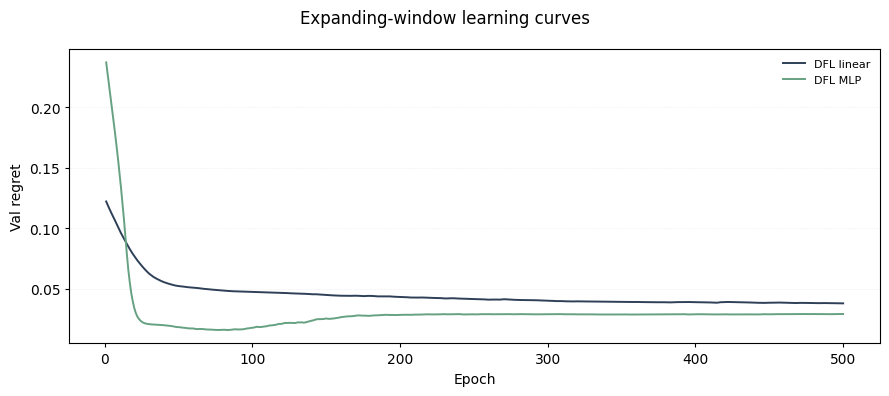

In [12]:
if not training_history.empty:
    for split_hist in [training_history]:
        # Pad each refit's history to the model's max epoch (last value carried forward)
        # so the per-epoch mean has constant composition despite early stopping.
        padded = []
        for model_name, mg in split_hist.groupby("model"):
            max_epoch = int(mg["epoch"].max())
            for _, g in mg.groupby("test_date"):
                gg = (g.sort_values("epoch").set_index("epoch")[["val_loss"]]
                       .reindex(range(1, max_epoch + 1)).ffill().reset_index())
                gg["model"] = model_name
                padded.append(gg)
        mean_history = (pd.concat(padded, ignore_index=True)
                        .groupby(["model", "epoch"], as_index=False)
                        .agg(mean_val_loss=("val_loss", "mean")))

        fig, ax = plt.subplots(figsize=(9, 4))
        for model_name, group in mean_history.groupby("model"):
            group = group.sort_values("epoch"); color = MODEL_COLORS.get(model_name, "grey")
            label = MODEL_LABELS.get(model_name, model_name)
            ax.plot(group["epoch"], group["mean_val_loss"], color=color, lw=1.4, label=label)
        ax.set_ylabel("Val regret"); ax.set_xlabel("Epoch")
        ax.grid(True, axis="y", lw=0.5, alpha=0.3, linestyle=":"); ax.legend(fontsize=8, frameon=False, loc="upper right")
        fig.suptitle("Expanding-window learning curves"); plt.tight_layout()
        fig_dir = FIGURES_DIR
        fig_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(fig_dir / "learning_curves.png", dpi=200, bbox_inches="tight"); plt.show()